# Week 7 — Advanced Model: XGBoost

## Objective

This notebook evaluates XGBoost as an advanced gradient-boosting model for predicting the closing prices of California single-family residences.

The Week 7 analysis has four objectives:

1. Train an XGBoost regression model using the same original feature set that produced the strongest Week 6 Random Forest performance.
2. Perform light hyperparameter tuning over:
   - maximum tree depth (`max_depth`);
   - learning rate (`learning_rate`);
   - number of boosting trees (`n_estimators`).
3. Evaluate the selected model on June 2026, the most recent unseen month.
4. Compare XGBoost with the models evaluated during Week 6.

This notebook does not rerun the Week 6 notebook. It directly loads the existing cleaned historical data through May 2026 and the June 2026 sold-property file.

The chronological evaluation design is:

- **Training-window length:** 15 months
- **Validation month:** May 2026
- **Final test month:** June 2026

May 2026 is used only for hyperparameter selection. June 2026 is reserved for final model evaluation.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Import Libraries

In [3]:
!pip install -q xgboost

In [2]:
import os
import json
import time
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 150)

RANDOM_SEED = 42
TARGET = "ClosePrice"

DATA_DIR = (
    "/content/drive/MyDrive/"
    "IDX_Exchange_Su26/data"
)

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "week7_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("XGBoost version:", xgb.__version__)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)

XGBoost version: 3.3.0
Data directory: /content/drive/MyDrive/IDX_Exchange_Su26/data
Output directory: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs


## 2. Load Existing Historical and June 2026 Data

The following existing files are loaded directly:

- the cleaned historical dataset covering January 2025 through May 2026;
- the newly available June 2026 CRMLS sold-property file.

Only the minimum transformations required to align the June records with the original Week 6 feature set are performed.

In [3]:
HISTORICAL_PATH = os.path.join(
    DATA_DIR,
    "crmls_sfr_avm_cleaned_enriched_202501_202605.csv"
)

JUNE_PATH = os.path.join(
    DATA_DIR,
    "CRMLSSold202606.csv"
)

if not os.path.exists(HISTORICAL_PATH):
    raise FileNotFoundError(
        "Historical cleaned dataset was not found at:\n"
        f"{HISTORICAL_PATH}"
    )

if not os.path.exists(JUNE_PATH):
    raise FileNotFoundError(
        "June 2026 dataset was not found at:\n"
        f"{JUNE_PATH}"
    )

historical_df = pd.read_csv(
    HISTORICAL_PATH,
    low_memory=False
)

june_df = pd.read_csv(
    JUNE_PATH,
    low_memory=False
)

print("Historical dataset loaded:")
print("Path:", HISTORICAL_PATH)
print("Shape:", historical_df.shape)

print("\nJune dataset loaded:")
print("Path:", JUNE_PATH)
print("Raw shape:", june_df.shape)

Historical dataset loaded:
Path: /content/drive/MyDrive/IDX_Exchange_Su26/data/crmls_sfr_avm_cleaned_enriched_202501_202605.csv
Shape: (181237, 93)

June dataset loaded:
Path: /content/drive/MyDrive/IDX_Exchange_Su26/data/CRMLSSold202606.csv
Raw shape: (24507, 78)


## 3. Filter and Prepare the June 2026 Records

The project scope is restricted to:

- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`

Records without a valid closing date or positive closing price cannot support model training or evaluation and are removed.

The same original features used by the Week 6 best-performing Random Forest are then constructed for the June records.

In [4]:
required_june_columns = [
    "PropertyType",
    "PropertySubType",
    "CloseDate",
    "ClosePrice"
]

missing_june_columns = [
    col
    for col in required_june_columns
    if col not in june_df.columns
]

if missing_june_columns:
    raise KeyError(
        "June data is missing required columns: "
        f"{missing_june_columns}"
    )

june_df = june_df[
    june_df["PropertyType"]
    .astype(str)
    .str.strip()
    .eq("Residential")
    &
    june_df["PropertySubType"]
    .astype(str)
    .str.strip()
    .eq("SingleFamilyResidence")
].copy()

june_df["CloseDate"] = pd.to_datetime(
    june_df["CloseDate"],
    errors="coerce"
)

june_df[TARGET] = pd.to_numeric(
    june_df[TARGET],
    errors="coerce"
)

june_df = june_df[
    june_df["CloseDate"].notna()
    & june_df[TARGET].notna()
    & (june_df[TARGET] > 0)
].copy()

print("June SFR rows:", len(june_df))

print(
    "June closing-date range:",
    june_df["CloseDate"].min(),
    "to",
    june_df["CloseDate"].max()
)

June SFR rows: 12858
June closing-date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00


In [5]:
# These are existing Week 6 old features, not new Week 7 features.

numeric_source_columns = [
    "YearBuilt",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "GarageSpaces",
    "Stories",
    "Latitude",
    "Longitude"
]

missing_indicator_sources = [
    "LivingArea",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "Stories"
]

for frame in [historical_df, june_df]:

    frame["CloseDate"] = pd.to_datetime(
        frame["CloseDate"],
        errors="coerce"
    )

    frame[TARGET] = pd.to_numeric(
        frame[TARGET],
        errors="coerce"
    )

    for col in numeric_source_columns:
        if col in frame.columns:
            frame[col] = pd.to_numeric(
                frame[col],
                errors="coerce"
            )

    # Property age at the time of closing
    frame["PropertyAge"] = (
        frame["CloseDate"].dt.year
        - frame["YearBuilt"]
    )

    frame.loc[
        (frame["PropertyAge"] < 0)
        | (frame["PropertyAge"] > 300),
        "PropertyAge"
    ] = np.nan

    # Cyclical month variables
    sale_month = frame["CloseDate"].dt.month

    frame["month_sin"] = np.sin(
        2 * np.pi * sale_month / 12
    )

    frame["month_cos"] = np.cos(
        2 * np.pi * sale_month / 12
    )

    # Recreate missing indicators consistently
    for col in missing_indicator_sources:
        if col in frame.columns:
            frame[f"{col}_missing"] = (
                frame[col]
                .isna()
                .astype(float)
            )

## 4. Combine the Historical and June Data

The historical and June records are aligned to the same schema and concatenated into one modeling dataset.

Duplicate records with nonmissing `ListingKey` values are removed while records without a listing key are retained.

In [6]:
combined_columns = sorted(
    set(historical_df.columns)
    | set(june_df.columns)
)

historical_aligned = historical_df.reindex(
    columns=combined_columns
)

june_aligned = june_df.reindex(
    columns=combined_columns
)

df = pd.concat(
    [
        historical_aligned,
        june_aligned
    ],
    ignore_index=True,
    sort=False
)

print(
    "Rows before duplicate handling:",
    len(df)
)

if "ListingKey" in df.columns:

    keyed_rows = (
        df[df["ListingKey"].notna()]
        .sort_values("CloseDate")
        .drop_duplicates(
            subset=["ListingKey"],
            keep="last"
        )
    )

    unkeyed_rows = df[
        df["ListingKey"].isna()
    ]

    df = pd.concat(
        [
            keyed_rows,
            unkeyed_rows
        ],
        ignore_index=True,
        sort=False
    )

df["CloseDate"] = pd.to_datetime(
    df["CloseDate"],
    errors="coerce"
)

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

df = df[
    df["CloseDate"].notna()
    & df[TARGET].notna()
    & (df[TARGET] > 0)
].copy()

df["close_month"] = (
    df["CloseDate"]
    .dt.to_period("M")
    .astype(str)
)

available_months = sorted(
    df["close_month"]
    .dropna()
    .unique()
)

print(
    "Rows after duplicate handling:",
    len(df)
)

print("\nAvailable months:")
print(available_months)

print("\nJune 2026 rows:")
print(
    (df["close_month"] == "2026-06")
    .sum()
)

if available_months[-1] != "2026-06":
    raise ValueError(
        "Expected June 2026 as the latest month, "
        f"but found {available_months[-1]}."
    )

Rows before duplicate handling: 194095
Rows after duplicate handling: 194085

Available months:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']

June 2026 rows:
12858


## 5. Define the Modeling Features and Prevent Leakage

The Week 6 best-performing model was the Random Forest using the original feature set. XGBoost therefore uses that same 27-feature specification so that the comparison is fair.

The following variables are excluded because they introduce leakage, are unavailable for off-market valuation, occur after listing or closing, or are identifiers:

- `ListPrice`
- `OriginalListPrice`
- `ClosePrice_to_ListPrice_ratio`
- `DaysOnMarket`
- closing and contract dates
- listing identifiers

In [7]:
LEAKAGE_COLUMNS = {
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice_to_ListPrice_ratio",
    "DaysOnMarket",
    "CloseDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate",
    "MlsStatus",
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "UnparsedAddress"
}

numeric_candidates = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "PropertyAge",
    "GarageSpaces",
    "Stories",
    "Latitude",
    "Longitude",
    "month_sin",
    "month_cos",
    "LivingArea_missing",
    "BathroomsTotalInteger_missing",
    "LotSizeSquareFeet_missing",
    "YearBuilt_missing",
    "GarageSpaces_missing",
    "Stories_missing"
]

categorical_candidates = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

numeric_features = [
    col
    for col in numeric_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

categorical_features = [
    col
    for col in categorical_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

feature_columns = (
    numeric_features
    + categorical_features
)

selected_leakage = (
    set(feature_columns)
    & LEAKAGE_COLUMNS
)

if selected_leakage:
    raise ValueError(
        "Leakage variables were selected: "
        f"{selected_leakage}"
    )

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of raw features:")
print(len(feature_columns))

Numerical features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'PropertyAge', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude', 'month_sin', 'month_cos', 'LivingArea_missing', 'BathroomsTotalInteger_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'GarageSpaces_missing', 'Stories_missing']

Categorical features:
['City', 'PostalCode', 'CountyOrParish', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

Number of raw features:
27


In [8]:
for col in numeric_features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).astype(float)

for col in categorical_features:

    missing_mask = df[col].isna()

    df[col] = df[col].astype(object)

    df.loc[
        ~missing_mask,
        col
    ] = (
        df.loc[
            ~missing_mask,
            col
        ]
        .astype(str)
    )

    df.loc[
        missing_mask,
        col
    ] = np.nan

print(
    "Data types prepared for scikit-learn and XGBoost."
)

missing_summary = (
    df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    "\nMissing values to be handled "
    "inside the training pipeline:"
)

print(
    missing_summary[
        missing_summary > 0
    ]
)

Data types prepared for scikit-learn and XGBoost.

Missing values to be handled inside the training pipeline:
WaterfrontYN             193978
BasementYN               189392
AttachedGarageYN          23264
Stories                   20955
ViewYN                    17483
PoolPrivateYN             15421
NewConstructionYN         14719
GarageSpaces               7540
LotSizeSquareFeet          3373
FireplaceYN                 140
PropertyAge                 131
LivingArea                  103
City                         84
BathroomsTotalInteger        20
Latitude                     17
Longitude                    17
PostalCode                    3
dtype: int64


## 6. Evaluation Metrics

R² is the required Week 7 test metric. Additional metrics are also reported:

- **MAE:** average absolute prediction error in dollars;
- **RMSE:** dollar error that gives greater weight to large misses;
- **MAPE:** average absolute percentage error;
- **MdAPE:** median absolute percentage error.

Reporting several metrics provides a more complete evaluation of real-estate valuation performance.

In [9]:
def calculate_metrics(
    y_true,
    y_pred
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    percentage_errors = (
        np.abs(
            y_true - y_pred
        )
        / np.abs(y_true)
    ) * 100

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "MAPE": (
            mean_absolute_percentage_error(
                y_true,
                y_pred
            )
            * 100
        ),

        "MdAPE": np.median(
            percentage_errors
        )
    }

## 7. Build the XGBoost Preprocessing Pipeline

Numerical variables are imputed using medians learned from training data.

Categorical variables are imputed using the most frequent training category and transformed through one-hot encoding. Unknown categories in later months are ignored rather than causing an error.

Feature scaling is not required because XGBoost uses decision trees.

In [10]:
def build_preprocessor():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=20
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

## 8. Create the Chronological Tuning Split

The optimal Week 6 training-window length was 15 months.

For XGBoost hyperparameter tuning:

- training covers the 15 months ending in April 2026;
- May 2026 is the validation month;
- June 2026 remains untouched.

The target-price outlier thresholds are learned from the tuning training data only and then applied unchanged to validation data.

In [11]:
BEST_X = 15

validation_month = "2026-05"
test_month = "2026-06"

validation_period = pd.Period(
    validation_month,
    freq="M"
)

test_period = pd.Period(
    test_month,
    freq="M"
)

tuning_train_end = (
    validation_period - 1
)

tuning_train_start = (
    tuning_train_end
    - (BEST_X - 1)
)

df_month_period = pd.PeriodIndex(
    df["close_month"],
    freq="M"
)

tuning_train_mask = (
    (df_month_period >= tuning_train_start)
    & (df_month_period <= tuning_train_end)
)

validation_mask = (
    df_month_period == validation_period
)

tuning_train_df = df.loc[
    tuning_train_mask
].copy()

validation_df = df.loc[
    validation_mask
].copy()

# Learn target bounds from tuning training data only
tuning_lower_price = (
    tuning_train_df[TARGET]
    .quantile(0.005)
)

tuning_upper_price = (
    tuning_train_df[TARGET]
    .quantile(0.995)
)

tuning_train_df = tuning_train_df[
    tuning_train_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

validation_df = validation_df[
    validation_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

X_tuning_train = tuning_train_df[
    feature_columns
]

y_tuning_train = tuning_train_df[
    TARGET
]

X_validation = validation_df[
    feature_columns
]

y_validation = validation_df[
    TARGET
]

print(
    "Tuning training period:",
    tuning_train_df[
        "close_month"
    ].min(),
    "to",
    tuning_train_df[
        "close_month"
    ].max()
)

print("Validation month:", validation_month)

print(
    "Tuning training rows:",
    len(tuning_train_df)
)

print(
    "Validation rows:",
    len(validation_df)
)

print(
    "Training-derived target bounds:",
    f"${tuning_lower_price:,.0f}",
    "to",
    f"${tuning_upper_price:,.0f}"
)

Tuning training period: 2025-02 to 2026-04
Validation month: 2026-05
Tuning training rows: 159478
Validation rows: 11897
Training-derived target bounds: $187,000 to $8,817,250


## 9. Fit the Preprocessor Once for Model Tuning

The preprocessing transformations are fitted once using the tuning training data. The fitted transformations are then applied unchanged to May 2026 validation data.

Because every candidate uses the same training and validation observations, preprocessing does not need to be repeated for each candidate.

In [12]:
tuning_preprocessor = build_preprocessor()

preprocessing_start = time.time()

X_tuning_train_processed = (
    tuning_preprocessor.fit_transform(
        X_tuning_train
    )
)

X_validation_processed = (
    tuning_preprocessor.transform(
        X_validation
    )
)

preprocessing_seconds = (
    time.time()
    - preprocessing_start
)

print(
    "Preprocessing completed in:",
    f"{preprocessing_seconds:.2f} seconds"
)

print(
    "Processed training shape:",
    X_tuning_train_processed.shape
)

print(
    "Processed validation shape:",
    X_validation_processed.shape
)

Preprocessing completed in: 6.67 seconds
Processed training shape: (159478, 1476)
Processed validation shape: (11897, 1476)


## 10. Light XGBoost Hyperparameter Tuning

A small manual search is used to tune the three parameters specified in the Week 7 task:

- `max_depth`;
- `learning_rate`;
- `n_estimators`.

Lower learning rates are paired with more boosting trees, while higher learning rates are paired with fewer trees. The search is intentionally limited to keep computation manageable.

In [13]:
xgb_candidates = [
    {
        "max_depth": 4,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 4,
        "learning_rate": 0.10,
        "n_estimators": 200
    },
    {
        "max_depth": 6,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 6,
        "learning_rate": 0.10,
        "n_estimators": 200
    },
    {
        "max_depth": 8,
        "learning_rate": 0.05,
        "n_estimators": 300
    },
    {
        "max_depth": 8,
        "learning_rate": 0.10,
        "n_estimators": 200
    }
]

print(
    "Number of XGBoost candidates:",
    len(xgb_candidates)
)

Number of XGBoost candidates: 6


In [14]:
TUNING_CHECKPOINT_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_tuning_checkpoint.csv"
)

xgb_tuning_results = []

for candidate_number, params in enumerate(
    xgb_candidates,
    start=1
):

    print("=" * 70)

    print(
        f"Running XGBoost candidate "
        f"{candidate_number}/"
        f"{len(xgb_candidates)}"
    )

    print("Parameters:", params)

    model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=params["max_depth"],
        learning_rate=params[
            "learning_rate"
        ],
        n_estimators=params[
            "n_estimators"
        ],
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0
    )

    start_time = time.time()

    model.fit(
        X_tuning_train_processed,
        y_tuning_train
    )

    validation_predictions = model.predict(
        X_validation_processed
    )

    fit_seconds = (
        time.time()
        - start_time
    )

    validation_metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    xgb_tuning_results.append({
        "max_depth": params[
            "max_depth"
        ],
        "learning_rate": params[
            "learning_rate"
        ],
        "n_estimators": params[
            "n_estimators"
        ],
        "Validation_R2": validation_metrics[
            "R2"
        ],
        "Validation_MAE": validation_metrics[
            "MAE"
        ],
        "Validation_RMSE": validation_metrics[
            "RMSE"
        ],
        "Validation_MAPE": validation_metrics[
            "MAPE"
        ],
        "Validation_MdAPE": validation_metrics[
            "MdAPE"
        ],
        "Fit_Seconds": fit_seconds
    })

    # Save completed candidates after every iteration
    pd.DataFrame(
        xgb_tuning_results
    ).to_csv(
        TUNING_CHECKPOINT_PATH,
        index=False
    )

    print(
        "Validation R²:",
        f"{validation_metrics['R2']:.4f}"
    )

    print(
        "Validation MAE:",
        f"${validation_metrics['MAE']:,.2f}"
    )

    print(
        "Fit time:",
        f"{fit_seconds:.1f} seconds"
    )

    print(
        "Checkpoint saved to:",
        TUNING_CHECKPOINT_PATH
    )

xgb_tuning_results_df = (
    pd.DataFrame(
        xgb_tuning_results
    )
    .sort_values(
        "Validation_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_tuning_results_df
)

Running XGBoost candidate 1/6
Parameters: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300}
Validation R²: 0.8047
Validation MAE: $255,985.69
Fit time: 10.1 seconds
Checkpoint saved to: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_tuning_checkpoint.csv
Running XGBoost candidate 2/6
Parameters: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200}
Validation R²: 0.8183
Validation MAE: $245,705.87
Fit time: 4.2 seconds
Checkpoint saved to: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_tuning_checkpoint.csv
Running XGBoost candidate 3/6
Parameters: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300}
Validation R²: 0.8447
Validation MAE: $221,482.62
Fit time: 16.0 seconds
Checkpoint saved to: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_tuning_checkpoint.csv
Running XGBoost candidate 4/6
Parameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200}
Validation R²: 0.8560

,max_depth,learning_rate,n_estimators,Validation_R2,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_MdAPE,Fit_Seconds
0,8,0.10,200,0.872388,193013.782675,356081.769101,15.444720,10.795260,31.805362
1,8,0.05,300,0.868052,196700.624217,362079.797040,15.732454,11.130965,26.549345
2,6,0.10,200,0.856019,212788.130553,378230.106572,17.498142,12.498739,4.246482
3,6,0.05,300,0.844739,221482.623060,392765.936270,18.368333,12.967888,16.048008
4,4,0.10,200,0.818291,245705.871411,424904.637170,20.734351,14.702441,4.224086
5,4,0.05,300,0.804684,255985.688071,440526.272396,21.886507,15.647970,10.136922


In [15]:
BEST_XGB_PARAMS = {
    "max_depth": int(
        xgb_tuning_results_df.loc[
            0,
            "max_depth"
        ]
    ),

    "learning_rate": float(
        xgb_tuning_results_df.loc[
            0,
            "learning_rate"
        ]
    ),

    "n_estimators": int(
        xgb_tuning_results_df.loc[
            0,
            "n_estimators"
        ]
    )
}

print("Best XGBoost parameters:")
print(BEST_XGB_PARAMS)

print(
    "\nBest validation R²:",
    f"{xgb_tuning_results_df.loc[0, 'Validation_R2']:.4f}"
)

print(
    "Best validation MAE:",
    f"${xgb_tuning_results_df.loc[0, 'Validation_MAE']:,.2f}"
)

Best XGBoost parameters:
{'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 200}

Best validation R²: 0.8724
Best validation MAE: $193,013.78


## 11. Create the Final Training and Test Sets

After selecting the XGBoost parameters using May 2026 validation performance, the 15-month training window is shifted forward by one month.

The final model is trained using the 15 months ending in May 2026 and evaluated once on June 2026.

The target-price bounds and preprocessing transformations are relearned using only the final training observations.

In [16]:
final_train_end = (
    test_period - 1
)

final_train_start = (
    final_train_end
    - (BEST_X - 1)
)

final_train_mask = (
    (df_month_period >= final_train_start)
    & (df_month_period <= final_train_end)
)

test_mask = (
    df_month_period == test_period
)

final_train_df = df.loc[
    final_train_mask
].copy()

test_df = df.loc[
    test_mask
].copy()

# Learn target bounds from final training data only
final_lower_price = (
    final_train_df[TARGET]
    .quantile(0.005)
)

final_upper_price = (
    final_train_df[TARGET]
    .quantile(0.995)
)

final_train_df = final_train_df[
    final_train_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()

test_df = test_df[
    test_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()

X_train = final_train_df[
    feature_columns
]

y_train = final_train_df[
    TARGET
]

X_test = test_df[
    feature_columns
]

y_test = test_df[
    TARGET
]

print(
    "Final training period:",
    final_train_df[
        "close_month"
    ].min(),
    "to",
    final_train_df[
        "close_month"
    ].max()
)

print("Test month:", test_month)

print(
    "Final training rows:",
    len(final_train_df)
)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Final training-derived target bounds:",
    f"${final_lower_price:,.0f}",
    "to",
    f"${final_upper_price:,.0f}"
)

Final training period: 2025-03 to 2026-05
Test month: 2026-06
Final training rows: 162619
Test rows: 12714
Final training-derived target bounds: $189,000 to $8,800,000


## 12. Train the Final XGBoost Model

In [17]:
final_preprocessor = build_preprocessor()

final_preprocessing_start = time.time()

X_train_processed = (
    final_preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    final_preprocessor.transform(
        X_test
    )
)

final_preprocessing_seconds = (
    time.time()
    - final_preprocessing_start
)

print(
    "Final preprocessing time:",
    f"{final_preprocessing_seconds:.2f} seconds"
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Final preprocessing time: 2.38 seconds
Processed training shape: (162619, 1483)
Processed test shape: (12714, 1483)


In [18]:
final_xgb_model = XGBRegressor(
    objective="reg:squarederror",

    max_depth=BEST_XGB_PARAMS[
        "max_depth"
    ],

    learning_rate=BEST_XGB_PARAMS[
        "learning_rate"
    ],

    n_estimators=BEST_XGB_PARAMS[
        "n_estimators"
    ],

    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)

training_start = time.time()

final_xgb_model.fit(
    X_train_processed,
    y_train
)

training_seconds = (
    time.time()
    - training_start
)

print(
    "Final XGBoost model trained successfully."
)

print(
    "Training time:",
    f"{training_seconds:.2f} seconds"
)

Final XGBoost model trained successfully.
Training time: 9.96 seconds


## 13. Evaluate the Final XGBoost Model

In [19]:
train_predictions = (
    final_xgb_model.predict(
        X_train_processed
    )
)

test_predictions = (
    final_xgb_model.predict(
        X_test_processed
    )
)

train_metrics = calculate_metrics(
    y_train,
    train_predictions
)

test_metrics = calculate_metrics(
    y_test,
    test_predictions
)

final_results_df = pd.DataFrame({
    "Model": [
        "XGBoost Regressor"
    ],

    "Feature_Set": [
        "Old Features"
    ],

    "Training_Window_Months": [
        BEST_X
    ],

    "Training_Start": [
        str(final_train_start)
    ],

    "Training_End": [
        str(final_train_end)
    ],

    "Test_Month": [
        test_month
    ],

    "max_depth": [
        BEST_XGB_PARAMS[
            "max_depth"
        ]
    ],

    "learning_rate": [
        BEST_XGB_PARAMS[
            "learning_rate"
        ]
    ],

    "n_estimators": [
        BEST_XGB_PARAMS[
            "n_estimators"
        ]
    ],

    "Train_R2": [
        train_metrics["R2"]
    ],

    "Test_R2": [
        test_metrics["R2"]
    ],

    "Test_MAE": [
        test_metrics["MAE"]
    ],

    "Test_RMSE": [
        test_metrics["RMSE"]
    ],

    "Test_MAPE": [
        test_metrics["MAPE"]
    ],

    "Test_MdAPE": [
        test_metrics["MdAPE"]
    ],

    "Fit_Seconds": [
        training_seconds
    ]
})

display(
    final_results_df
)

,Model,Feature_Set,Training_Window_Months,Training_Start,Training_End,Test_Month,max_depth,learning_rate,n_estimators,Train_R2,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_MdAPE,Fit_Seconds
0,XGBoost Regressor,Old Features,15,2025-03,2026-05,2026-06,8,0.1,200,0.920337,0.871927,189511.452117,354459.779834,15.488394,10.588939,9.955992


## 14. Compare XGBoost with the Week 6 Models

The existing Week 6 model-results CSV is loaded directly. No Week 6 models are retrained.

Because all models were evaluated using June 2026 as the test month, their results can be compared directly.

In [20]:
WEEK6_RESULTS_PATH = os.path.join(
    DATA_DIR,
    "week6_outputs",
    "week6_old_vs_new_model_results.csv"
)

if os.path.exists(WEEK6_RESULTS_PATH):

    week6_results_df = pd.read_csv(
        WEEK6_RESULTS_PATH
    )

    print(
        "Week 6 results loaded from:",
        WEEK6_RESULTS_PATH
    )

else:

    print(
        "Week 6 results CSV was not found. "
        "Using the previously recorded Week 6 results."
    )

    week6_results_df = pd.DataFrame([
        {
            "Model": "Decision Tree",
            "Feature_Set": "New Features",
            "Test_R2": 0.744898,
            "Test_MAE": 268148.942390,
            "Test_MAPE": 20.754168,
            "Test_MdAPE": 13.887164
        },
        {
            "Model": "Decision Tree",
            "Feature_Set": "Old Features",
            "Test_R2": 0.765430,
            "Test_MAE": 254213.446343,
            "Test_MAPE": 19.689088,
            "Test_MdAPE": 13.084628
        },
        {
            "Model": "Linear Regression",
            "Feature_Set": "New Features",
            "Test_R2": 0.826683,
            "Test_MAE": 243221.390141,
            "Test_MAPE": 21.995113,
            "Test_MdAPE": 15.441967
        },
        {
            "Model": "Linear Regression",
            "Feature_Set": "Old Features",
            "Test_R2": 0.823956,
            "Test_MAE": 244910.828202,
            "Test_MAPE": 22.503345,
            "Test_MdAPE": 15.905356
        },
        {
            "Model": "Random Forest",
            "Feature_Set": "New Features",
            "Test_R2": 0.858225,
            "Test_MAE": 187169.393242,
            "Test_MAPE": 14.483501,
            "Test_MdAPE": 8.978567
        },
        {
            "Model": "Random Forest",
            "Feature_Set": "Old Features",
            "Test_R2": 0.870224,
            "Test_MAE": 174078.449019,
            "Test_MAPE": 13.107908,
            "Test_MdAPE": 7.885330
        }
    ])

display(
    week6_results_df
)

Week 6 results loaded from: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_old_vs_new_model_results.csv


,Feature_Set,Model,Number_of_Raw_Features,Training_Window_Months,Training_Start,Training_End,Test_Month,Train_R2,Test_R2,Test_MAE,Test_RMSE,Test_MAPE,Test_MdAPE,Fit_Seconds
0,New Features,Decision Tree,33,15,2025-03,2026-05,2026-06,0.846986,0.744898,268148.942390,500258.974844,20.754168,13.887164,4.318441
1,Old Features,Decision Tree,27,15,2025-03,2026-05,2026-06,0.845201,0.765430,254213.446343,479705.506107,19.689088,13.084628,3.967001
2,New Features,Linear Regression,33,15,2025-03,2026-05,2026-06,0.835676,0.826683,243221.390141,412342.621668,21.995113,15.441967,41.110221
3,Old Features,Linear Regression,27,15,2025-03,2026-05,2026-06,0.824791,0.823956,244910.828202,415574.246850,22.503345,15.905356,28.164887
4,New Features,Random Forest,33,15,2025-03,2026-05,2026-06,0.983396,0.858225,187169.393242,372939.616102,14.483501,8.978567,249.873887
5,Old Features,Random Forest,27,15,2025-03,2026-05,2026-06,0.983992,0.870224,174078.449019,356808.929213,13.107908,7.885330,169.475494


In [21]:
# Comparison Table
week6_best_result = (
    week6_results_df
    .sort_values(
        "Test_R2",
        ascending=False
    )
    .iloc[0]
)

comparison_df = pd.DataFrame([
    {
        "Model": (
            f"{week6_best_result['Model']} "
            f"({week6_best_result['Feature_Set']})"
        ),
        "Test_R2": week6_best_result[
            "Test_R2"
        ],
        "Test_MAE": week6_best_result[
            "Test_MAE"
        ],
        "Test_MAPE": week6_best_result[
            "Test_MAPE"
        ],
        "Test_MdAPE": week6_best_result[
            "Test_MdAPE"
        ]
    },
    {
        "Model": "XGBoost Regressor",
        "Test_R2": test_metrics["R2"],
        "Test_MAE": test_metrics["MAE"],
        "Test_MAPE": test_metrics[
            "MAPE"
        ],
        "Test_MdAPE": test_metrics[
            "MdAPE"
        ]
    }
])

week6_best_r2 = float(
    week6_best_result[
        "Test_R2"
    ]
)

comparison_df[
    "R2_Change_vs_Week6_Best"
] = (
    comparison_df["Test_R2"]
    - week6_best_r2
)

display(
    comparison_df
)

,Model,Test_R2,Test_MAE,Test_MAPE,Test_MdAPE,R2_Change_vs_Week6_Best
0,Random Forest (Old Features),0.870224,174078.449019,13.107908,7.885330,0.000000
1,XGBoost Regressor,0.871927,189511.452117,15.488394,10.588939,0.001703


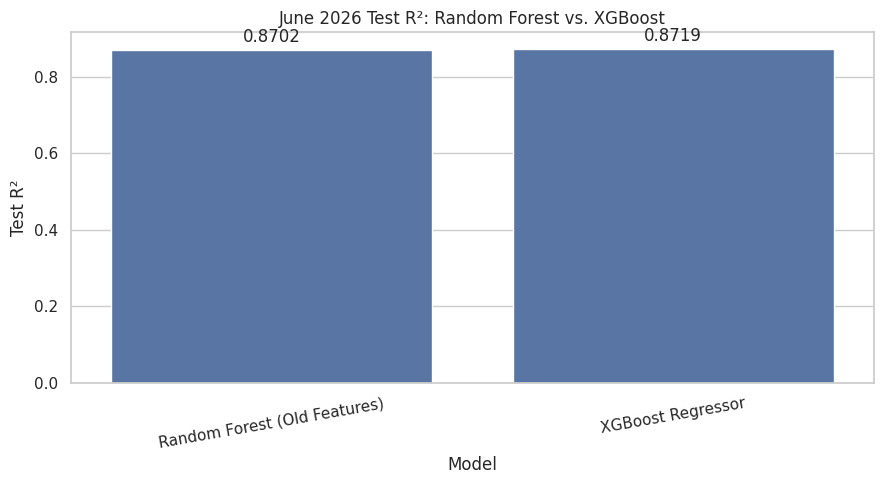

In [22]:
# Comparison Chart
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test_R2"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.title(
    "June 2026 Test R²: "
    "Random Forest vs. XGBoost"
)

plt.xlabel("Model")
plt.ylabel("Test R²")

plt.xticks(
    rotation=10
)

plt.tight_layout()
plt.show()

## 15. Actual vs. Predicted Closing Prices

The dashed diagonal line represents perfect predictions. Points closer to the line indicate more accurate predictions.

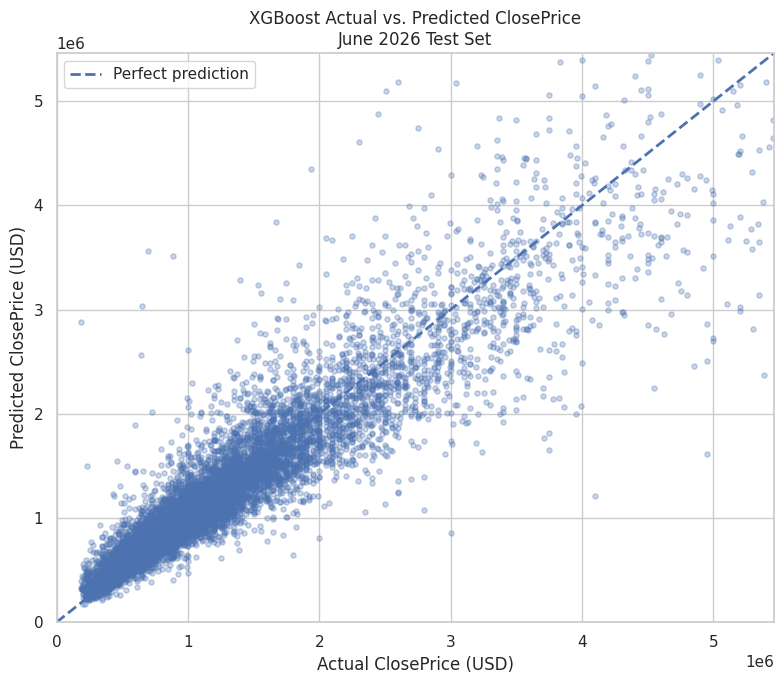

In [23]:
prediction_df = pd.DataFrame({
    "Actual_ClosePrice": (
        y_test.to_numpy()
    ),

    "Predicted_ClosePrice": (
        test_predictions
    )
})

plot_limit = max(
    prediction_df[
        "Actual_ClosePrice"
    ].quantile(0.99),

    prediction_df[
        "Predicted_ClosePrice"
    ].quantile(0.99)
)

plt.figure(figsize=(8, 7))

plt.scatter(
    prediction_df[
        "Actual_ClosePrice"
    ],

    prediction_df[
        "Predicted_ClosePrice"
    ],

    alpha=0.3,
    s=14
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)

plt.title(
    "XGBoost Actual vs. Predicted ClosePrice\n"
    "June 2026 Test Set"
)

plt.xlabel(
    "Actual ClosePrice (USD)"
)

plt.ylabel(
    "Predicted ClosePrice (USD)"
)

plt.legend()
plt.tight_layout()
plt.show()

## 16. XGBoost Feature Importance

Feature importance indicates how useful each processed feature was to the fitted XGBoost model.

These values describe predictive usefulness within the model and should not be interpreted as causal effects.

In [24]:
processed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame({
    "Feature": (
        processed_feature_names
    ),

    "Importance": (
        final_xgb_model
        .feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.head(20)
)

,Feature,Importance
0,categorical__CountyOrParish_San Diego,0.051514
1,categorical__CountyOrParish_San Bernardino,0.035634
2,categorical__CountyOrParish_Santa Clara,0.032646
3,categorical__CountyOrParish_Riverside,0.024526
4,categorical__City_Oceanside,0.023854
5,categorical__CountyOrParish_San Mateo,0.023520
6,categorical__CountyOrParish_Orange,0.016886
7,categorical__City_Newport Beach,0.015538
8,categorical__City_Santa Monica,0.013707
9,categorical__City_Corona Del Mar,0.012279


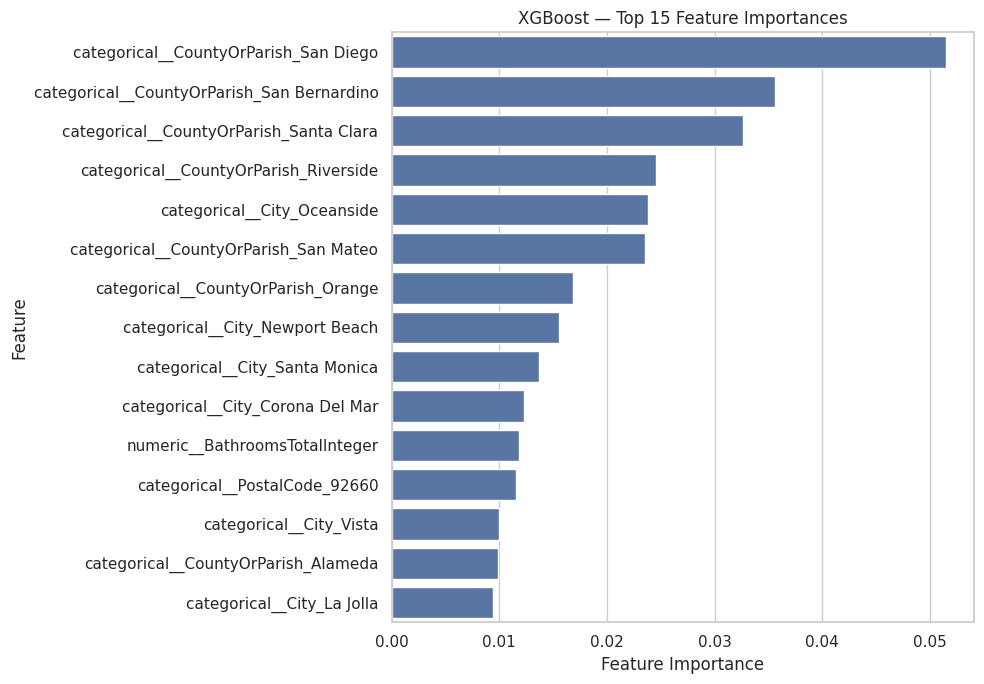

In [25]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "XGBoost — Top 15 Feature Importances"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

## 17. XGBoost Model Behavior

### Strengths

- XGBoost builds trees sequentially, allowing later trees to correct errors made by earlier trees.
- It captures nonlinear relationships and complex interactions among property and location variables.
- Tree depth, learning rate, and boosting rounds provide direct control over model complexity.
- Histogram-based tree construction is efficient for large tabular datasets.
- XGBoost often performs strongly on structured regression problems.

### Weaknesses

- XGBoost requires more hyperparameter tuning than Linear Regression or a single Decision Tree.
- Excessive depth or too many boosting rounds may lead to overfitting.
- A low learning rate may require more trees and longer training time.
- The model is less interpretable than Linear Regression or a shallow Decision Tree.
- Feature importance reflects predictive use rather than causality.

## 18. Save Week 7 Results and Model Artifacts

In [26]:
FINAL_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_test_metrics.csv"
)

TUNING_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_tuning_results.csv"
)

COMPARISON_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_model_comparison.csv"
)

PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_test_predictions.csv"
)

IMPORTANCE_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_feature_importance.csv"
)

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_model.joblib"
)

PREPROCESSOR_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_preprocessor.joblib"
)

METADATA_PATH = os.path.join(
    OUTPUT_DIR,
    "week7_xgboost_metadata.json"
)

final_results_df.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

xgb_tuning_results_df.to_csv(
    TUNING_RESULTS_PATH,
    index=False
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

feature_importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

joblib.dump(
    final_xgb_model,
    MODEL_PATH
)

joblib.dump(
    final_preprocessor,
    PREPROCESSOR_PATH
)

metadata = {
    "model": "XGBRegressor",
    "feature_set": "Old Features",
    "training_window_months": BEST_X,
    "validation_month": validation_month,
    "test_month": test_month,
    "best_parameters": BEST_XGB_PARAMS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_lower_bound": float(
        final_lower_price
    ),
    "target_upper_bound": float(
        final_upper_price
    ),
    "test_metrics": {
        key: float(value)
        for key, value
        in test_metrics.items()
    }
}

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=2
    )

print("Saved final metrics:", FINAL_RESULTS_PATH)
print("Saved tuning results:", TUNING_RESULTS_PATH)
print("Saved model comparison:", COMPARISON_PATH)
print("Saved test predictions:", PREDICTIONS_PATH)
print("Saved feature importance:", IMPORTANCE_PATH)
print("Saved trained model:", MODEL_PATH)
print("Saved preprocessor:", PREPROCESSOR_PATH)
print("Saved metadata:", METADATA_PATH)

Saved final metrics: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_test_metrics.csv
Saved tuning results: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_tuning_results.csv
Saved model comparison: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_model_comparison.csv
Saved test predictions: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_test_predictions.csv
Saved feature importance: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_feature_importance.csv
Saved trained model: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_model.joblib
Saved preprocessor: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_preprocessor.joblib
Saved metadata: /content/drive/MyDrive/IDX_Exchange_Su26/data/week7_outputs/week7_xgboost_metadata.json


In [27]:
print("WEEK 7 ADVANCED MODEL SUMMARY")
print("=" * 70)

print("Model: XGBoost Regressor")
print("Feature set: Old Features")
print("Training window:", BEST_X, "months")
print("Validation month:", validation_month)
print("Test month:", test_month)

print("\nBest hyperparameters:")
print(BEST_XGB_PARAMS)

print("\nFinal XGBoost results:")

print(
    f"Train R²: "
    f"{train_metrics['R2']:.4f}"
)

print(
    f"Test R²: "
    f"{test_metrics['R2']:.4f}"
)

print(
    f"Test MAE: "
    f"${test_metrics['MAE']:,.2f}"
)

print(
    f"Test RMSE: "
    f"${test_metrics['RMSE']:,.2f}"
)

print(
    f"Test MAPE: "
    f"{test_metrics['MAPE']:.2f}%"
)

print(
    f"Test MdAPE: "
    f"{test_metrics['MdAPE']:.2f}%"
)

print(
    "\nR² change versus Week 6 "
    "best Random Forest:"
)

print(
    f"{test_metrics['R2'] - week6_best_r2:+.4f}"
)

WEEK 7 ADVANCED MODEL SUMMARY
Model: XGBoost Regressor
Feature set: Old Features
Training window: 15 months
Validation month: 2026-05
Test month: 2026-06

Best hyperparameters:
{'max_depth': 8, 'learning_rate': 0.1, 'n_estimators': 200}

Final XGBoost results:
Train R²: 0.9203
Test R²: 0.8719
Test MAE: $189,511.45
Test RMSE: $354,459.78
Test MAPE: 15.49%
Test MdAPE: 10.59%

R² change versus Week 6 best Random Forest:
+0.0017


## Conclusion

This Week 7 analysis evaluated XGBoost as an advanced gradient-boosting model for predicting California single-family residence closing prices.

A light hyperparameter search was conducted over maximum tree depth, learning rate, and number of boosting trees. May 2026 was used for validation, while June 2026 remained reserved as the final unseen test set.

The selected XGBoost configuration used:

- `max_depth = 8`
- `learning_rate = 0.10`
- `n_estimators = 200`

The final XGBoost model achieved:

- Training R²: **0.9203**
- Test R²: **0.8719**
- Test MAE: **$189,511.45**
- Test RMSE: **354,459.78 dollars**
- Test MAPE: **15.49%**
- Test MdAPE: **10.59%**

The best-performing Week 6 Random Forest achieved a June 2026 test R² of **0.8702**. XGBoost slightly outperformed this benchmark by **0.0017**, or approximately **0.17 percentage points**.

Although XGBoost achieved the highest test R², the improvement over Random Forest was very small. In addition, Random Forest produced lower prediction errors, with an MAE of approximately **$174,078**, a MAPE of **13.11%**, and a MdAPE of **7.89%**, compared with the higher error values produced by XGBoost.

Overall, the results do not indicate that XGBoost is clearly superior across all evaluation metrics. XGBoost explained slightly more variation in June 2026 closing prices, but Random Forest generated more accurate dollar and percentage predictions. Therefore, model selection depends on the project objective: XGBoost may be preferred when maximizing R² is the primary goal, while Random Forest remains the more balanced model when both explanatory performance and prediction-error metrics are considered.